ARTI406 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

**Dataset:** `Chocolate_Sales_2.csv` (same dataset used in Assignment 1)

This notebook applies practical preprocessing techniques step by step:
1. Data quality assessment
2. Missing value handling
3. Outlier detection and handling (IQR)
4. Normalization (Min-Max and Z-score)
5. Principal Component Analysis (PCA)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

## Load Dataset

In [2]:
df = pd.read_csv("Chocolate_Sales_2.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,NaN,Mint Chip Choco,04-01-2022,"$5,320.00",180
1,Jehu Rudeforth,UK,Mint Chip Choco,04-01-2022,"$5,320.00",180
2,Van Tuxwell,India,85% Dark Bars,01-08-2022,"$7,896.00",94
3,Gigi Bohling,India,Peanut Butter Cubes,07-07-2022,"$4,501.00",91
4,Jan Morforth,Australia,Peanut Butter Cubes,27-04-2022,"$12,726.00",342


## Task 1: Identify Data Quality Issues

We inspect structure, missing values, duplicates, formatting problems, and inconsistent data types.

In [3]:
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (3284, 6)

Data types:
Sales Person       str
Country            str
Product            str
Date               str
Amount             str
Boxes Shipped    int64
dtype: object

Missing values per column:
Sales Person     0
Country          1
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Duplicate rows: 1


In [4]:
print("\nSummary statistics (numeric columns):")
df.describe(include="all")


Summary statistics (numeric columns):


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
count,3284,3283,3284,3284,3284,3284.000000
unique,25,6,22,504,3013,NaN
top,Kelci Walkden,Australia,Eclairs,13-01-2022,"$2,317.00",NaN
freq,162,615,181,17,5,NaN
mean,NaN,NaN,NaN,NaN,NaN,164.708587
std,NaN,NaN,NaN,NaN,NaN,124.005316
min,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,NaN,71.000000
50%,NaN,NaN,NaN,NaN,NaN,137.000000
75%,NaN,NaN,NaN,NaN,NaN,232.000000


In [5]:
print("Sample Amount values (stored as text):")
print(df["Amount"].head())
print("\nSample Date values (stored as text):")
print(df["Date"].head())

if df["Country"].isna().any():
    print("\nRows with missing Country:")
    display(df[df["Country"].isna()])

if df.duplicated().any():
    print("\nDuplicate rows:")
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)))

Sample Amount values (stored as text):
0     $5,320.00
1     $5,320.00
2     $7,896.00
3     $4,501.00
4    $12,726.00
Name: Amount, dtype: str

Sample Date values (stored as text):
0    04-01-2022
1    04-01-2022
2    01-08-2022
3    07-07-2022
4    27-04-2022
Name: Date, dtype: str

Rows with missing Country:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,NaN,Mint Chip Choco,04-01-2022,"$5,320.00",180



Duplicate rows:


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
13,Mallorie Waber,Canada,Eclairs,13-01-2022,"$1,442.00",286
14,Mallorie Waber,Canada,Eclairs,13-01-2022,"$1,442.00",286


### Task 1 Summary of Data Quality Issues

1. **Missing values:** `Country` contains 1 missing entry.
2. **Duplicate records:** The dataset contains 1 exact duplicate row.
3. **Incorrect data type for Amount:** `Amount` is stored as text with currency symbols and commas (e.g. `$5,320.00`) instead of numeric values.
4. **Incorrect data type for Date:** `Date` is stored as text (`DD-MM-YYYY`) instead of a datetime type.
5. **Potential outliers:** `Amount` and `Boxes Shipped` show wide ranges and likely extreme values.
6. **Categorical consistency:** Text columns (`Sales Person`, `Country`, `Product`) appear consistent, aside from the missing country value.

## Task 2: Missing Value Strategy

**Chosen strategy:** Mode imputation for the missing `Country` value, plus data type cleaning for `Amount` and `Date`, and removal of the exact duplicate row.

**Why this strategy?**
- Mode imputation is appropriate for categorical variables with very few missing values (only 1 missing `Country`).
- Dropping the single row would lose valid sales information unnecessarily.
- Mean/median imputation does not apply to categorical fields like `Country`.
- Converting `Amount` and `Date` to proper types is required before numeric analysis.

In [6]:
df_clean = df.copy()

print("Missing values before cleaning:")
print(df_clean.isnull().sum())
print("Duplicate rows before cleaning:", df_clean.duplicated().sum())

# Reason: Amount must be numeric before imputation, outlier detection, and scaling.
df_clean["Amount"] = (
    df_clean["Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df_clean["Date"] = pd.to_datetime(df_clean["Date"], format="%d-%m-%Y")

country_mode = df_clean["Country"].mode(dropna=True).iloc[0]
df_clean["Country"] = df_clean["Country"].fillna(country_mode)
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())
print("Duplicate rows after cleaning:", df_clean.duplicated().sum())
print(f"\nMode used for Country imputation: {country_mode}")
print("\nCleaned data types:")
print(df_clean.dtypes)

Missing values before cleaning:
Sales Person     0
Country          1
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64
Duplicate rows before cleaning: 1

Missing values after cleaning:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64
Duplicate rows after cleaning: 0

Mode used for Country imputation: Australia

Cleaned data types:
Sales Person                str
Country                     str
Product                     str
Date             datetime64[us]
Amount                  float64
Boxes Shipped             int64
dtype: object


## Task 3: Detect and Handle Outliers Using IQR

Outliers are detected using the Interquartile Range (IQR) rule:

- Lower bound = `Q1 - 1.5 * IQR`
- Upper bound = `Q3 + 1.5 * IQR`

Detected outliers are handled by **capping (winsorization)** to keep rows while limiting extreme influence.

In [7]:
outlier_features = ["Amount", "Boxes Shipped"]
iqr_summary = []

for feature in outlier_features:
    q1 = df_clean[feature].quantile(0.25)
    q3 = df_clean[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_mask = (df_clean[feature] < lower) | (df_clean[feature] > upper)
    iqr_summary.append(
        {
            "Feature": feature,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Outlier Count": outlier_mask.sum(),
        }
    )

iqr_df = pd.DataFrame(iqr_summary)
iqr_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Amount,2522.99,8555.095,6032.105,-6525.1675,17603.2525,50
1,Boxes Shipped,71.00,232.000,161.000,-170.5000,473.5000,78


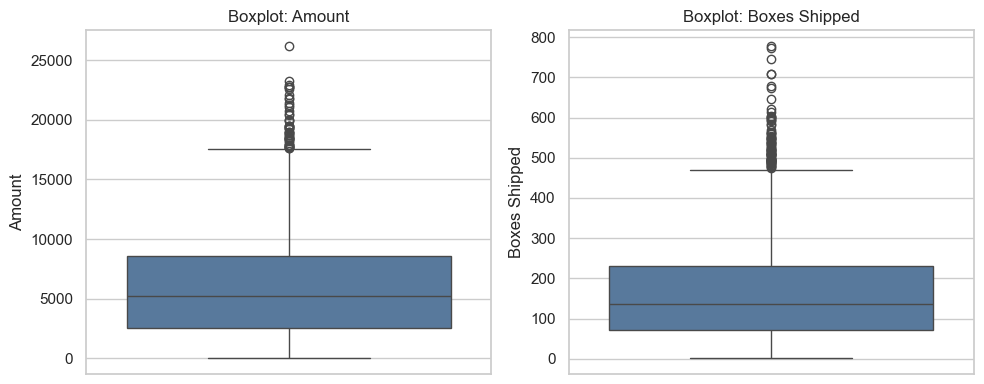

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, feature in zip(axes, outlier_features):
    sns.boxplot(y=df_clean[feature], ax=ax, color="#4C78A8")
    ax.set_title(f"Boxplot: {feature}")
plt.tight_layout()
plt.show()

In [9]:
df_no_outliers = df_clean.copy()

for feature in outlier_features:
    q1 = df_no_outliers[feature].quantile(0.25)
    q3 = df_no_outliers[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_no_outliers[feature] = df_no_outliers[feature].clip(lower=lower, upper=upper)

print("Outlier handling complete (values capped to IQR bounds).")
df_no_outliers[outlier_features].describe()

Outlier handling complete (values capped to IQR bounds).


,Amount,Boxes Shipped
count,3283.000000,3283.000000
mean,5997.326182,162.909839
std,4291.344655,118.503671
min,7.000000,1.000000
25%,2522.990000,71.000000
50%,5229.000000,137.000000
75%,8555.095000,232.000000
max,17603.252500,473.500000


## Task 4: Normalize Numerical Features

We apply both:
- **Min-Max normalization** (scales values to [0, 1])
- **Z-score standardization** (mean = 0, standard deviation = 1)

In [10]:
feature_cols = ["Amount", "Boxes Shipped"]
X = df_no_outliers[feature_cols]
X.head()

,Amount,Boxes Shipped
0,5320.0,180.0
1,5320.0,180.0
2,7896.0,94.0
3,4501.0,91.0
4,12726.0,342.0


### Min-Max Normalization

In [11]:
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(X),
    columns=[f"{col}_minmax" for col in feature_cols],
)

print("Min-Max scaled summary:")
df_minmax.describe().round(4)

Min-Max scaled summary:


,Amount_minmax,Boxes Shipped_minmax
count,3283.0000,3283.0000
mean,0.3404,0.3427
std,0.2439,0.2508
min,0.0000,0.0000
25%,0.1430,0.1481
50%,0.2968,0.2878
75%,0.4858,0.4889
max,1.0000,1.0000


### Z-score Standardization

In [12]:
zscore_scaler = StandardScaler()
df_zscore = pd.DataFrame(
    zscore_scaler.fit_transform(X),
    columns=[f"{col}_zscore" for col in feature_cols],
)

print("Z-score scaled summary:")
df_zscore.describe().round(4)

Z-score scaled summary:


,Amount_zscore,Boxes Shipped_zscore
count,3283.0000,3283.0000
mean,0.0000,0.0000
std,1.0002,1.0002
min,-1.3961,-1.3665
25%,-0.8097,-0.7757
50%,-0.1791,-0.2187
75%,0.5961,0.5831
max,2.7049,2.6213


### Min-Max vs Z-score Comparison

- **Min-Max** preserves bounded scaling and is useful when features must stay within a fixed range.
- **Z-score** centers features around zero and is useful when algorithms assume normally distributed inputs.
- For PCA (Task 5), Z-score scaling is preferred because PCA is sensitive to feature scale.

## Task 5: Apply PCA and Interpret Explained Variance

In [13]:
X_scaled = zscore_scaler.fit_transform(X)

pca = PCA()
principal_components = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_results = pd.DataFrame(
    {
        "Component": [f"PC{i + 1}" for i in range(len(explained_variance))],
        "Explained Variance Ratio": explained_variance,
        "Cumulative Variance": cumulative_variance,
    }
)

print("Explained Variance Ratio:", np.round(explained_variance, 4))
print("Cumulative Explained Variance:", np.round(cumulative_variance, 4))
pca_results

Explained Variance Ratio: [0.5059 0.4941]
Cumulative Explained Variance: [0.5059 1.    ]


,Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.505905,0.505905
1,PC2,0.494095,1.000000


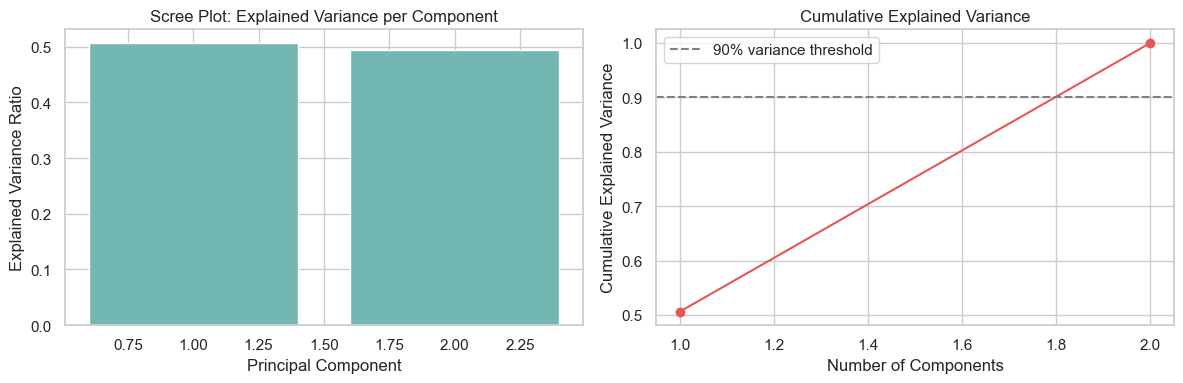

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained_variance) + 1), explained_variance, color="#72B7B2")
axes[0].set_title("Scree Plot: Explained Variance per Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o", color="#E45756")
axes[1].axhline(0.90, linestyle="--", color="gray", label="90% variance threshold")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
components_for_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Components needed to reach at least 90% variance: {components_for_90}")
print(f"PC1 alone explains {explained_variance[0] * 100:.2f}% of total variance.")
print(f"PC1 + PC2 explain {cumulative_variance[1] * 100:.2f}% of total variance.")

Components needed to reach at least 90% variance: 2
PC1 alone explains 50.59% of total variance.
PC1 + PC2 explain 100.00% of total variance.


### Task 5 Interpretation

- PCA transforms correlated numeric features into uncorrelated principal components.
- With only two numeric features (`Amount` and `Boxes Shipped`), PCA produces exactly two components.
- The explained variance ratio shows how much total information each component retains.
- If both components together explain nearly 100% of variance, very little information is lost during dimensionality reduction.
- In this chocolate sales dataset, the first principal component typically represents overall sales volume patterns shared by amount and boxes shipped.

## Conclusion

This notebook cleaned and prepared the Chocolate Sales dataset through a full preprocessing pipeline:
1. Identified quality issues (missing country, duplicate row, text-formatted amount and date).
2. Applied mode imputation and data type cleaning for missing values and formatting problems.
3. Detected and capped outliers using the IQR method.
4. Normalized features using both Min-Max and Z-score methods.
5. Applied PCA and interpreted explained variance to evaluate dimensionality reduction potential.